In [8]:
import pandas as pd
from google.colab import drive
import matplotlib.pyplot as plt
import seaborn as sns

drive.mount('/content/drive')
df = pd.read_excel("/content/drive/My Drive/data/Main_Data_Bank.xlsx")

numeric_cols = df.select_dtypes(include=['number']).columns
categorical_cols = df.select_dtypes(exclude=['number']).columns

numeric_summary = df[numeric_cols].describe().T
numeric_summary["missing_values"] = df[numeric_cols].isnull().sum()
numeric_summary = numeric_summary[["min","max","mean","50%","std","missing_values"]]
numeric_summary.rename(columns={"50%":"median"}, inplace=True)

categorical_summary = {}
for col in categorical_cols:
    categorical_summary[col] = {
        "unique_values": df[col].dropna().unique().tolist(),
        "missing_values": df[col].isnull().sum()
    }

print(numeric_summary)

print("\n")
for col, stats in categorical_summary.items():
    print(f"{col}:")
    print(f"  distinct categories: {stats['unique_values']}")
    print(f"  missing values: {stats['missing_values']}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
                                                 min           max  \
ID NR (anonymisert dummy)                        1.0  3.705300e+04   
Tilskudd i USD                                   0.0  7.275778e+05   
Kompleks produksjon (1/0)                        0.0  1.000000e+00   
NY KOMMUNESCORE                                  0.0  2.000000e+01   
NY KOMMUNESKÅRE FRITID                           0.0  2.000000e+01   
Andre dyr                                        0.0  1.000000e+00   
Annet fjørfe                                     0.0  1.000000e+00   
Bær                                              0.0  1.000000e+00   
Bier                                             0.0  1.000000e+00   
Blomster                                         0.0  1.000000e+00   
Drivhus                                          0.0  1.000000e+00   
Drivhus kg                     

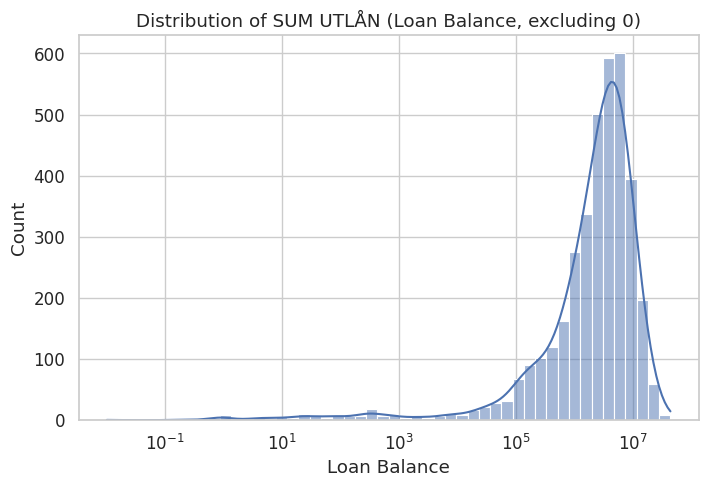

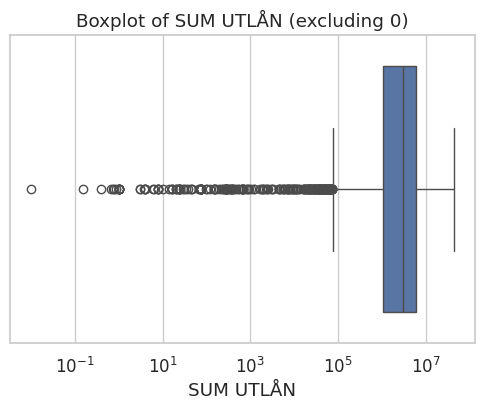

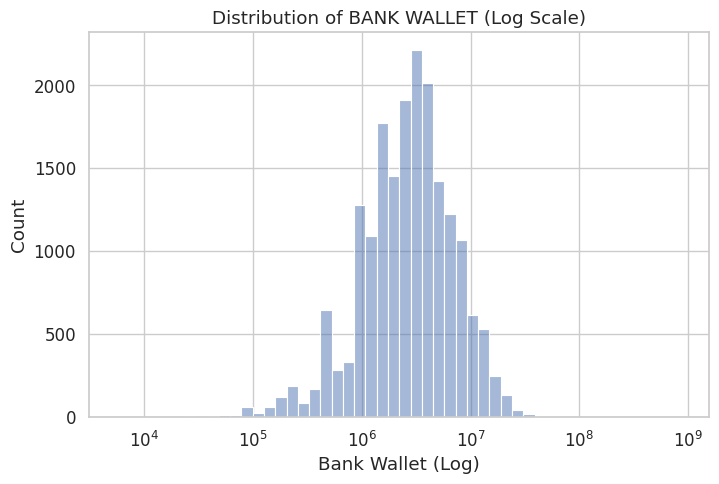

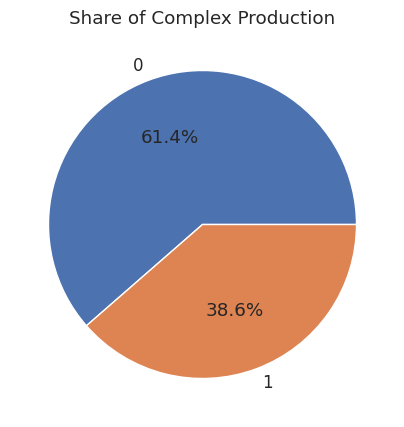

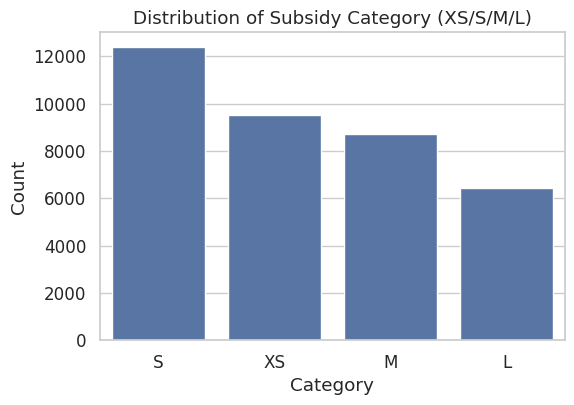

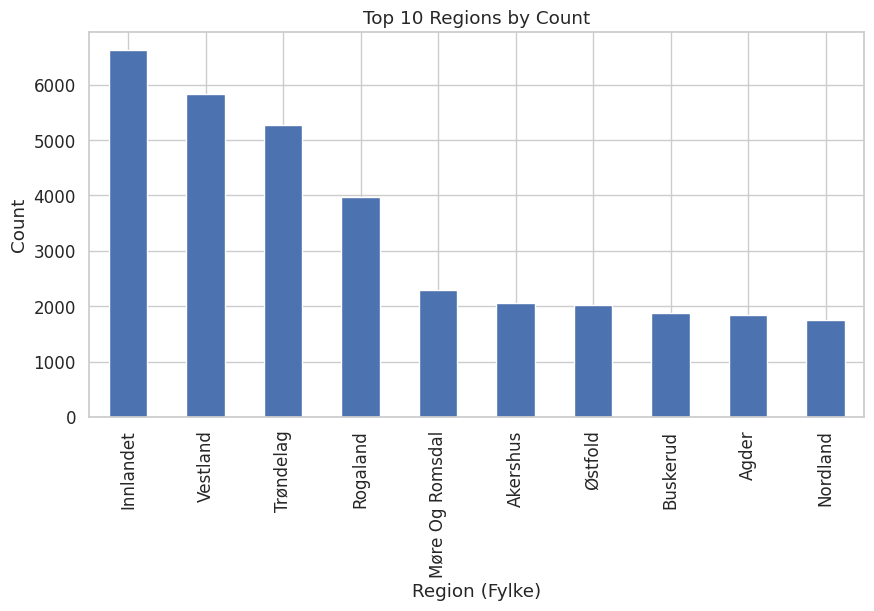

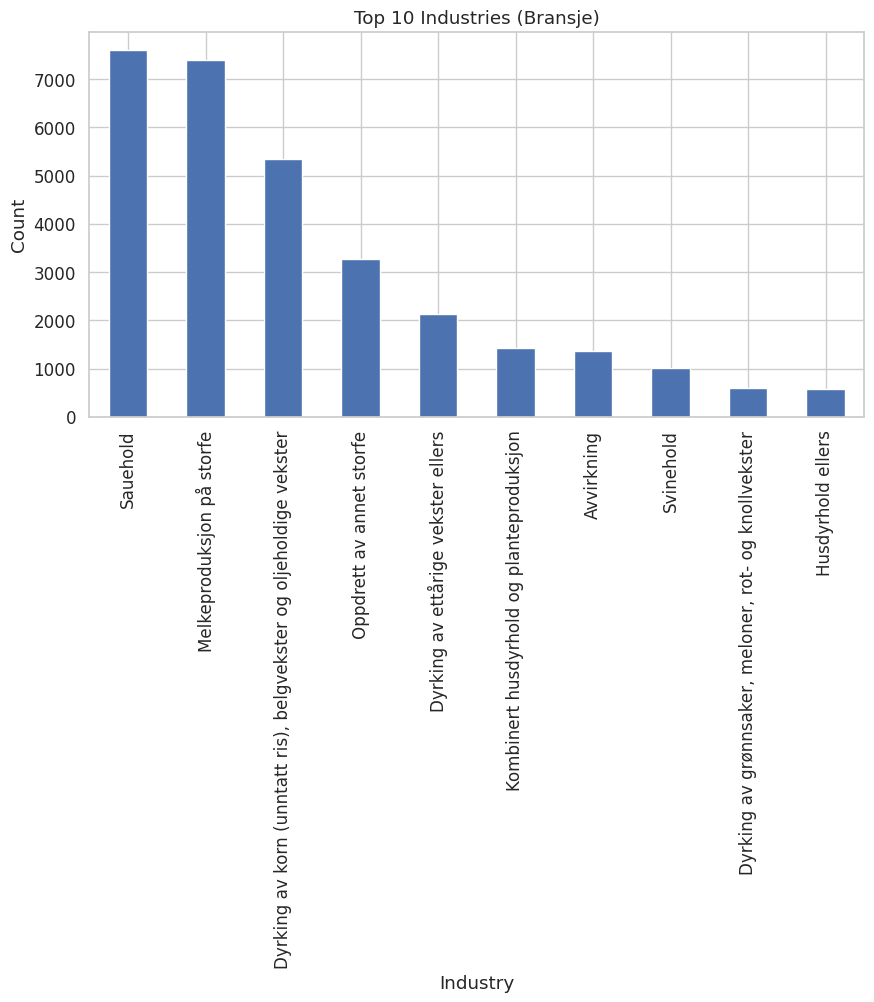

In [9]:

sns.set(style="whitegrid", font_scale=1.1)

# 1. SUM UTLÅN
loan_data = df[df["SUM UTLÅN"] != 0]["SUM UTLÅN"] * -1

plt.figure(figsize=(8,5))
sns.histplot(loan_data, bins=50, log_scale=True, kde=True)
plt.title("Distribution of SUM UTLÅN (Loan Balance, excluding 0)")
plt.xlabel("Loan Balance")
plt.ylabel("Count")
plt.show()

plt.figure(figsize=(6,4))
sns.boxplot(x=loan_data, log_scale=True)
plt.title("Boxplot of SUM UTLÅN (excluding 0)")
plt.show()

# 2. BANK WALLET
plt.figure(figsize=(8,5))
sns.histplot(df["BANK WALLET"], bins=50, log_scale=True, kde=True)
plt.title("Distribution of BANK WALLET (Log Scale)")
plt.xlabel("Bank Wallet (Log)")
plt.ylabel("Count")
plt.show()

# 3. Kompleks produksjon (1/0)
plt.figure(figsize=(5,5))
df["Kompleks produksjon (1/0)"].value_counts().plot.pie(autopct='%1.1f%%')
plt.title("Share of Complex Production")
plt.ylabel("")
plt.show()

# 4. NY tilskuddskategori
plt.figure(figsize=(6,4))
sns.countplot(x="NY tilskuddskategori", data=df, order=df["NY tilskuddskategori"].value_counts().index)
plt.title("Distribution of Subsidy Category (XS/S/M/L)")
plt.xlabel("Category")
plt.ylabel("Count")
plt.show()

# 5. Fylke Top10
plt.figure(figsize=(10,5))
df["Fylke"].value_counts().head(10).plot.bar()
plt.title("Top 10 Regions by Count")
plt.xlabel("Region (Fylke)")
plt.ylabel("Count")
plt.show()

# 6. Bransje Top10
plt.figure(figsize=(10,5))
df["Bransje"].value_counts().head(10).plot.bar()
plt.title("Top 10 Industries (Bransje)")
plt.xlabel("Industry")
plt.ylabel("Count")
plt.show()